# CNN vs Transfer Learning using ResNet18

## Project Overview

Transfer learning has become one of the most effective techniques for training deep learning models on small datasets. Instead of learning image features entirely from scratch, pre-trained models can leverage knowledge acquired from large-scale datasets to achieve higher accuracy with significantly fewer training samples.

In this project, three different approaches are compared on a binary image classification task using the Cats vs Dogs Mini Dataset:

- **CNN trained from scratch**
- **Frozen ResNet18 (Feature Extraction)**
- **Fine-tuned ResNet18**

The objective is to evaluate how transfer learning improves classification performance compared to a conventional CNN trained entirely from scratch.

---

## Project Information

| Item | Details |
|------|---------|
| Framework | PyTorch |
| Programming Language | Python |
| Dataset | Cats vs Dogs Mini Dataset |
| Models Evaluated | CNN, Frozen ResNet18, Fine-tuned ResNet18 |
| Task | Binary Image Classification |
| Evaluation Metric | Classification Accuracy |
| Objective | Compare training from scratch with transfer learning |

## Import Required Libraries

The following libraries are used for data preprocessing, model development, training, visualization, and evaluation throughout this notebook.

In [2]:
import torch
import torchvision

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader
from torch.utils.data import random_split

from torch import nn
from torch import optim

import matplotlib.pyplot as plt
import numpy as np

## Dataset Location

This notebook expects the project datasets to be available inside the local **data/** directory.

Dataset structure:

data/
└── cats_and_dogs/
    ├── train/
    │   ├── cats/
    │   └── dogs/
    └── test/
        ├── cats/
        └── dogs/

The dataset can be downloaded separately as described in the repository documentation.

In [ ]:
dataset_path = "../data/cats_and_dogs"

## Hardware Configuration

Deep learning models can be trained on either a CPU or a GPU. To improve training speed, this notebook automatically detects whether a CUDA-enabled GPU is available and uses it when possible. If no GPU is detected, the models will run on the CPU.

This makes the notebook portable across different environments without requiring code changes.

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## Dataset Description

This project uses the **Cats vs Dogs Mini Dataset**, a binary image classification dataset containing images from two classes:

- Cat
- Dog

The dataset is intentionally small, making it an excellent benchmark for studying the benefits of transfer learning. Training a deep CNN from scratch on a limited dataset is often difficult because the model must learn visual features without sufficient training examples. Transfer learning addresses this challenge by leveraging knowledge learned from large-scale datasets such as ImageNet.

### Dataset Characteristics

- Binary image classification
- Approximately 1,000 RGB images
- Balanced class distribution
- Input image size resized to **224 × 224** pixels

## Data Preprocessing

Before training, all images undergo a sequence of preprocessing transformations to ensure consistency and compatibility with the neural network.

The preprocessing pipeline includes:

- Resizing all images to 224 × 224 pixels
- Converting images into tensors
- Normalizing pixel values using ImageNet statistics

Using ImageNet normalization allows the pre-trained ResNet18 model to operate under the same input distribution used during its original training.

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Dataset Preparation

The dataset is loaded using TorchVision's **ImageFolder** utility, which automatically assigns labels based on the folder names.

After loading, the dataset is split into training and validation subsets to evaluate each model on unseen data during training.

In [ ]:
dataset = datasets.ImageFolder(
    dataset_path,
    transform=transform
)

['cats', 'dogs']
1000


In [7]:
# Split dataset
train_size = int(0.8 * len(dataset))

val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32
)

## Visualizing Sample Images

Before training the models, it is useful to inspect a few examples from the dataset. Visualizing randomly selected training images helps verify that the preprocessing pipeline has been applied correctly and confirms that the dataset has been loaded successfully.

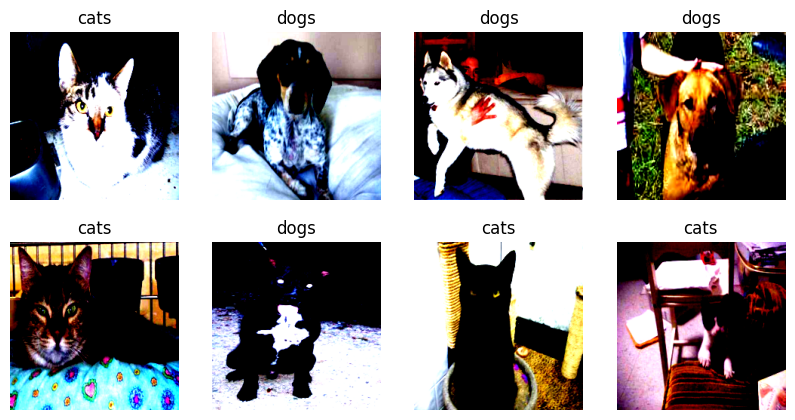

In [9]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    2,
    4,
    figsize=(10,5)
)

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1,2,0)

    ax.imshow(img)

    ax.set_title(
        dataset.classes[labels[i]]
    )

    ax.axis("off")

plt.show()

# Experiment 1 — CNN Trained from Scratch

In this experiment, a convolutional neural network is trained entirely from randomly initialized weights. The purpose of this experiment is to establish a baseline performance for comparison with transfer learning approaches.

Since the model has no prior knowledge of visual features, it must learn edges, textures, shapes, and object representations directly from the training images.

## CNN Architecture

The baseline model consists of multiple convolutional layers followed by pooling operations and fully connected layers.

This architecture is intentionally simple and serves as a reference point for evaluating the effectiveness of transfer learning.

In [10]:
# CNN Model
class SimpleCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64*28*28,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                2
            )
        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

## Training the Baseline CNN

The CNN is trained using the Cross Entropy Loss function, which is commonly used for multi-class classification problems.

The Adam optimizer is selected because it adapts learning rates automatically and generally provides faster convergence than traditional stochastic gradient descent.

In [11]:
# Create Model
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
# Training Function (created once and is reused)
def train_model(model, epochs=5):

    train_losses=[]

    for epoch in range(epochs):

        model.train()

        running_loss=0

        for images, labels in train_loader:

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss/len(train_loader)

        train_losses.append(avg_loss)

        print(
            f"Epoch {epoch+1}: {avg_loss:.4f}"
        )

    return train_losses

In [13]:
cnn_losses = train_model(model)

Epoch 1: 0.7968
Epoch 2: 0.6872
Epoch 3: 0.6451
Epoch 4: 0.6260
Epoch 5: 0.5838


## Model Evaluation

After training, the CNN is evaluated on the validation dataset.

Classification accuracy is used as the primary evaluation metric and serves as the baseline for comparison with transfer learning models.

In [14]:
# Accuracy Function
def evaluate(model):

    model.eval()

    correct=0
    total=0

    with torch.no_grad():

        for images, labels in val_loader:

            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)

            _, pred = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                pred == labels
            ).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [15]:
cnn_accuracy = evaluate(model)

print(cnn_accuracy)

61.5


# Experiment 2 – Transfer Learning using Frozen ResNet18

After establishing the baseline performance of a CNN trained from scratch, the next experiment evaluates **transfer learning** using a pre-trained ResNet18 model.

Instead of learning visual features from the beginning, the network leverages knowledge acquired from the large-scale ImageNet dataset. In this experiment, all pre-trained convolutional layers are **frozen**, meaning their weights remain unchanged during training. Only the final fully connected classification layer is replaced and trained on the Cats vs Dogs dataset.

This approach significantly reduces training time while often achieving higher accuracy on small datasets.

## Frozen ResNet18 Architecture

ResNet18 is a deep convolutional neural network consisting of residual (skip) connections that help overcome the vanishing gradient problem encountered in very deep networks.

The original classification layer is replaced with a new fully connected layer containing two output neurons corresponding to the two target classes (Cat and Dog). During this experiment, only the new classifier is trainable while all feature extraction layers remain frozen.

In [18]:
model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]


In [19]:
# Freeze all layers:
for param in model.parameters():
    param.requires_grad = False

In [20]:
# Replace final layer
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

In [21]:
# Move to GPU
model = model.to(device)

## Training Frozen ResNet18

The modified ResNet18 model is trained using the Adam optimizer and Cross Entropy Loss.

Since only the final classification layer is updated, the network learns to map the already extracted visual features to the target classes without modifying the pre-trained feature extractor. This makes training computationally efficient while retaining the rich representations learned from ImageNet.

In [ ]:
# Loss:
criterion = nn.CrossEntropyLoss()

In [ ]:
# Optimizer
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [25]:
# Now train:
frozen_losses = train_model(model)

Epoch 1: 0.4628
Epoch 2: 0.2318
Epoch 3: 0.1501
Epoch 4: 0.1454
Epoch 5: 0.1238


## Model Evaluation

After training, the Frozen ResNet18 model is evaluated on the validation dataset.

The classification accuracy obtained in this experiment is compared directly with the baseline CNN to measure the benefit of transfer learning using a fixed feature extractor.

In [26]:
frozen_accuracy = evaluate(model)

print(frozen_accuracy)

97.0


## Results and Observations

The Frozen ResNet18 model demonstrates a significant improvement over the CNN trained from scratch. Since the model already possesses generalized visual feature representations learned from ImageNet, it requires only minimal training to adapt to the new classification task.

This experiment highlights one of the primary advantages of transfer learning—high accuracy with limited training data and reduced computational cost.

# Experiment 3 – Fine-Tuning ResNet18

While freezing the feature extractor already provides excellent performance, additional improvements can often be achieved through **fine-tuning**.

In this experiment, selected layers of the pre-trained ResNet18 model are unfrozen, allowing the network to adjust previously learned feature representations specifically for the Cats vs Dogs dataset. This enables the model to better capture task-specific patterns while still benefiting from pre-trained knowledge.

## Fine-Tuned ResNet18 Architecture

The same pre-trained ResNet18 architecture is used as in the previous experiment. However, unlike the frozen model, the deeper layers of the network are allowed to update during training.

This enables the network to refine high-level image features according to the target dataset while preserving the general low-level features learned during pre-training.

In [27]:
model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

In [28]:
# Freeze everything first.
for param in model.parameters():
    param.requires_grad = False

In [29]:
# Unfreeze Layer 4
# This is the last convolution block.
for param in model.layer4.parameters():
    param.requires_grad = True

In [30]:
# Replace classifier
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

In [31]:
# Move to GPU
model = model.to(device)

In [32]:
# Loss
criterion = nn.CrossEntropyLoss()

In [33]:
# Optimizer
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.0001
)

## Training Fine-Tuned ResNet18

The model is trained using the Adam optimizer and Cross Entropy Loss.

Unlike the previous experiment, both the newly added classifier and the unfrozen layers participate in backpropagation. Although this increases the computational cost, it often leads to improved performance by allowing the feature extractor to adapt to the new task.

In [35]:
# Train
finetune_losses = train_model(model)

Epoch 1: 0.1743
Epoch 2: 0.0346
Epoch 3: 0.0087
Epoch 4: 0.0062
Epoch 5: 0.0038


## Model Evaluation

The fine-tuned ResNet18 model is evaluated using the same validation dataset and evaluation metric as the previous experiments.

The resulting accuracy is compared with both the baseline CNN and the Frozen ResNet18 model to determine whether fine-tuning provides additional performance gains.

In [36]:
finetune_accuracy = evaluate(model)

print(finetune_accuracy)

99.5


# Performance Comparison

The three experiments are compared to evaluate the effectiveness of transfer learning.

The comparison highlights the progression from a CNN trained entirely from scratch to transfer learning with a frozen feature extractor and finally to a fine-tuned pre-trained model. This analysis demonstrates how increasing the use of pre-trained knowledge improves classification performance on a relatively small dataset.

## Accuracy Comparison Graph

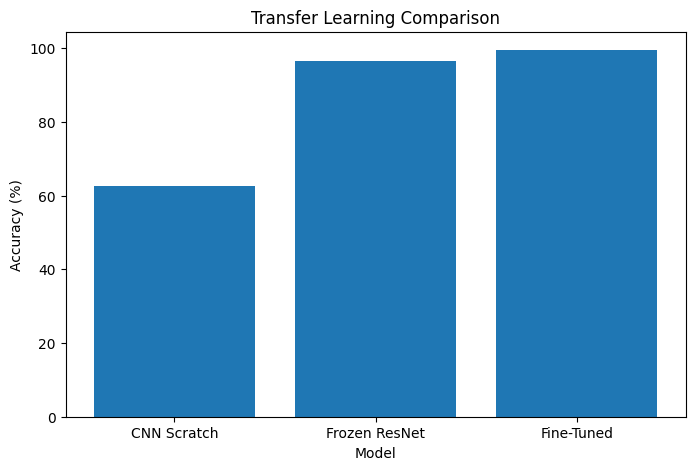

In [ ]:
model_names = [
    "CNN Scratch",
    "Frozen ResNet18",
    "Fine-Tuned ResNet18"
]

accuracies = [
    cnn_accuracy,
    frozen_accuracy,
    finetune_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Transfer Learning Comparison")

plt.show()

## Loss Comparison Graph


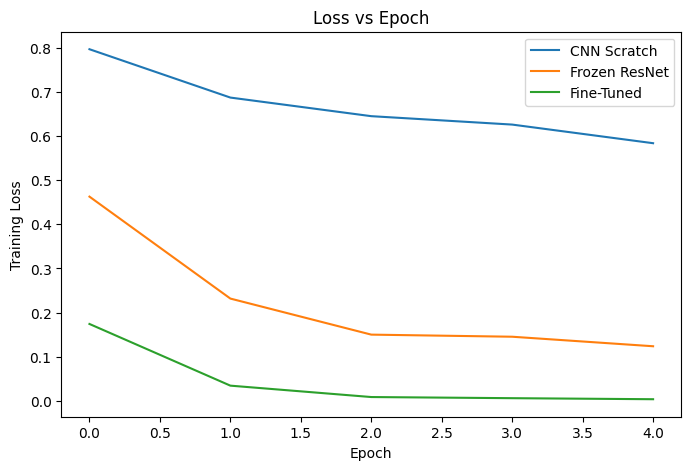

In [38]:
plt.figure(figsize=(8,5))

plt.plot(cnn_losses, label="CNN Scratch")

plt.plot(frozen_losses, label="Frozen ResNet")

plt.plot(finetune_losses, label="Fine-Tuned")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title("Loss vs Epoch")

plt.legend()

plt.show()

# Model Inference on a Sample Image

To demonstrate the practical application of the trained model, a random image from the dataset is selected and passed through the best-performing model for prediction. The predicted class is then compared with the actual image content to qualitatively assess the model's performance.

In [39]:
from PIL import Image

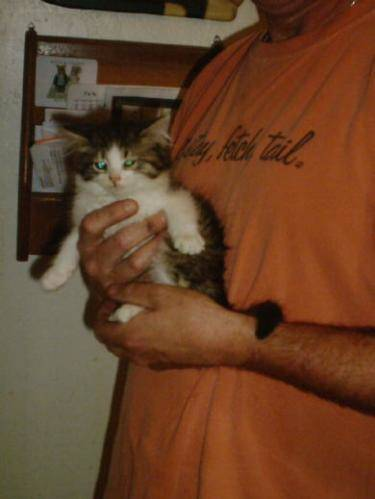

In [ ]:
import random
import glob
from PIL import Image

# Collect all images from both classes
images = (
    glob.glob(dataset_path + "/cats/*.jpg") +
    glob.glob(dataset_path + "/dogs/*.jpg")
)

image_path = random.choice(images)

image = Image.open(image_path)
image

In [42]:
# Predict:
transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img = transform_test(image)

img = img.unsqueeze(0)

img = img.to(device)

model.eval()

with torch.no_grad():
    output = model(img)
    prediction = torch.argmax(output,1)

classes = ["cats","dogs"]

print(
    "Prediction:",
    classes[prediction.item()]
)

Prediction: cats


# Conclusion

This study compared three different approaches for binary image classification using the Cats vs Dogs dataset.

The CNN trained from scratch served as the baseline model, while the Frozen ResNet18 and Fine-Tuned ResNet18 models leveraged transfer learning to improve performance. The experimental results demonstrate that transfer learning significantly outperforms conventional CNN training on small datasets, with the fine-tuned ResNet18 achieving the highest overall accuracy.

These findings reinforce the importance of transfer learning as an efficient and effective strategy for computer vision tasks when labeled data is limited.

### Final Results

| Model | Accuracy (%) |
|---------|---------|
| CNN From Scratch | 61.5 |
| Frozen ResNet18 | 97 |
| Fine-Tuned ResNet18 | 99.5 |

### Observations

- The CNN trained from scratch achieved the lowest performance because the dataset was relatively small.
- The Frozen ResNet18 model achieved significantly higher accuracy by utilizing features learned from ImageNet.
- The Fine-Tuned ResNet18 model achieved the highest accuracy because it was able to adapt pre-trained features to the cats and dogs classification task.
- Training loss decreased much faster for the transfer learning models compared to the CNN trained from scratch.

### Key Learning

Transfer Learning is highly effective for small datasets. Reusing knowledge from a large pre-trained model greatly improves classification performance while reducing training time and computational cost.

The experiment demonstrates why Transfer Learning is one of the most widely used techniques in modern computer vision applications.

# Key Takeaways

- Training a CNN from scratch requires substantially more data to achieve competitive performance.
- Transfer learning enables the reuse of rich visual features learned from large-scale datasets.
- Freezing the feature extractor provides excellent performance while minimizing training time.
- Fine-tuning selected layers further improves accuracy by adapting learned representations to the target dataset.
- Transfer learning is an effective solution for image classification problems involving limited training data.

---

# Future Improvements

Possible extensions of this project include:

- Experimenting with deeper architectures such as ResNet50 or EfficientNet.
- Applying data augmentation techniques to improve model generalization.
- Evaluating additional optimization algorithms and learning rate schedulers.
- Testing the models on larger and more diverse image datasets.
- Deploying the best-performing model as a web application for real-time image classification.